In [ ]:



    MULTIVARIABLE REGRESSION ANALYSIS




In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [5]:
# 1. Define the Input Data
x1 = np.array([0, 5, 15, 25, 35, 45, 55, 60])
x2 = np.array([1, 1, 2, 5, 11, 15, 34, 35])
y = np.array([4, 5, 20, 14, 32, 22, 38, 43])

# Combine X1 and X2 into a single matrix for processing
X = np.column_stack((x1, x2))

print("Feature Matrix (X):")
print(X)
print(f"\nTarget Vector (y): {y}")

Feature Matrix (X):
[[ 0  1]
 [ 5  1]
 [15  2]
 [25  5]
 [35 11]
 [45 15]
 [55 34]
 [60 35]]

Target Vector (y): [ 4  5 20 14 32 22 38 43]


In [6]:
# --- Method 1: Manual Calculation (Using Matrix Algebra) ---

# Step A: Add a column of ones to X (for the Intercept term b0)
# This creates a matrix of shape (n_samples, 3) -> [1, x1, x2]
X_b = np.c_[np.ones((len(x1), 1)), X]

# Step B: Apply the Normal Equation: theta = inv(X_transpose * X) * X_transpose * y
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

# Extract coefficients
intercept_manual = theta_best[0]
b1_manual = theta_best[1]
b2_manual = theta_best[2]

# Make Predictions: y = b0 + b1*x1 + b2*x2
y_pred_manual = X_b.dot(theta_best)

print("--- Manual Method Results ---")
print(f"Intercept (b0): {intercept_manual:.4f}")
print(f"Coefficient X1 (b1): {b1_manual:.4f}")
print(f"Coefficient X2 (b2): {b2_manual:.4f}")

--- Manual Method Results ---
Intercept (b0): 5.5226
Coefficient X1 (b1): 0.4471
Coefficient X2 (b2): 0.2550


In [7]:
# Calculate Errors
mse_manual = np.mean((y - y_pred_manual)**2)
rmse_manual = np.sqrt(mse_manual)

print(f"MSE: {mse_manual:.4f}")
print(f"RMSE: {rmse_manual:.4f}")

MSE: 25.5619
RMSE: 5.0559


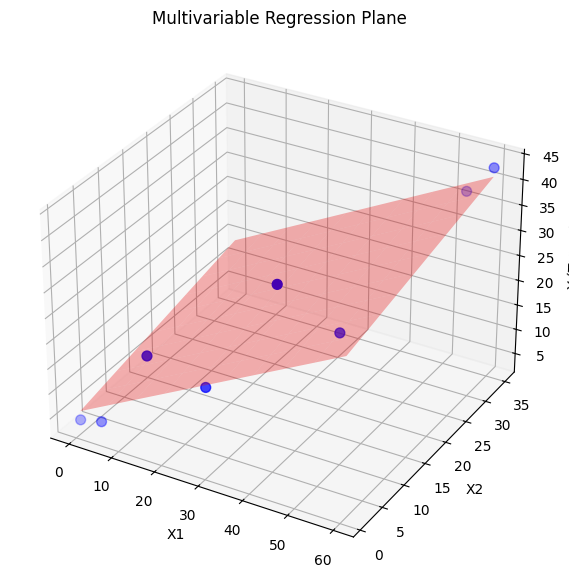

In [8]:
# --- Visualization: 3D Scatter Plot with Plane ---
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# 1. Plot actual data points
ax.scatter(x1, x2, y, color='blue', label='Actual Data', s=50)

# 2. Create a meshgrid to plot the regression plane
x1_surf, x2_surf = np.meshgrid(np.linspace(x1.min(), x1.max(), 10), 
                               np.linspace(x2.min(), x2.max(), 10))
y_surf = intercept_manual + b1_manual * x1_surf + b2_manual * x2_surf

# 3. Plot the surface
ax.plot_surface(x1_surf, x2_surf, y_surf, color='red', alpha=0.3)

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('Y (Target)')
ax.set_title('Multivariable Regression Plane')
plt.show()

In [ ]:
# --- Method 2: Using Built-in Functions (Scikit-Learn) and an External Dataset ---
Here is how you can perform the exact same analysis using the `scikit-learn` library's built-in `LinearRegression` model, and `pandas` to manage the dataset.

In [ ]:
# Create a Pandas DataFrame to simulate loading a dataset
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Simulating a dataset (e.g., normally you would do pd.read_csv('dataset.csv'))
data = {
    'Feature1': x1,
    'Feature2': x2,
    'Target': y
}
df = pd.DataFrame(data)

print("Dataset Head:")
print(df.head())

# 1. Separate features (X) and target (y) from the dataset
X_features = df[['Feature1', 'Feature2']]
y_target = df['Target']

# 2. Initialize the Linear Regression model
model = LinearRegression()

# 3. Fit the model using the dataset
model.fit(X_features, y_target)

# 4. View coefficients and intercept
print("\n--- Scikit-Learn Model Results ---")
print(f"Intercept (b0): {model.intercept_:.4f}")
print(f"Coefficient X1 (b1): {model.coef_[0]:.4f}")
print(f"Coefficient X2 (b2): {model.coef_[1]:.4f}")

# 5. Make predictions
y_pred_sklearn = model.predict(X_features)

# 6. Calculate Error metrics via built in sklearn functions
mse_sklearn = mean_squared_error(y_target, y_pred_sklearn)
rmse_sklearn = np.sqrt(mse_sklearn)

print(f"MSE: {mse_sklearn:.4f}")
print(f"RMSE: {rmse_sklearn:.4f}")

In [ ]:
# --- Visualization: 3D Scatter Plot with Plane (Scikit-Learn) ---

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# 1. Plot actual data points
ax.scatter(df['Feature1'], df['Feature2'], df['Target'], color='green', label='Actual Data', s=50)

# 2. Create a meshgrid to plot the regression plane
x1_surf_sk, x2_surf_sk = np.meshgrid(np.linspace(df['Feature1'].min(), df['Feature1'].max(), 10), 
                                     np.linspace(df['Feature2'].min(), df['Feature2'].max(), 10))

# 3. Predict y values for the meshgrid points
# Flatten the meshgrid arrays to feed into the model
mesh_features = pd.DataFrame({'Feature1': x1_surf_sk.flatten(), 'Feature2': x2_surf_sk.flatten()})
y_surf_sk = model.predict(mesh_features).reshape(x1_surf_sk.shape)

# 4. Plot the surface
ax.plot_surface(x1_surf_sk, x2_surf_sk, y_surf_sk, color='orange', alpha=0.3)

ax.set_xlabel('Feature 1 (X1)')
ax.set_ylabel('Feature 2 (X2)')
ax.set_zlabel('Target (Y)')
ax.set_title('Multivariable Regression Plane (Scikit-Learn)')
plt.show()